# RT_spherical + Monte Carlo two-level iteration

This notebook follows example_disort.ipynb, but replaces the DISORT update with solve_rt_spherical. The spherical solver transports local shell emission along chord paths and keeps the optional central beam flux as a separate inverse-square attenuated term.


In [1]:
import sys
sys.path.append('../')


In [2]:
import csv

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import Constants as constants
from ComaGrid import ComaGrid
from Einstein_coeff import einstein_coeffs_B
from Electron_collision import electron_collision_rate
from Molecular_collision import detailed_balance_excitation_rate, molecular_collision_rate
from profiles import calc_density, temperature_inverse_distance, electron_biver_1997
from Solar_pumping import scale_g_factors_from_1au
from Statistical_equilibrium import monte_carlo_two_level_populations
from RT_spherical import solve_rt_spherical


In [3]:
data_path = '../data/r_lev0_2.5au.csv'
profile = np.loadtxt(data_path, delimiter=',')
radius_km = profile[::-1, 0]

# RT_spherical expects the coma grid to start at the far end and move inward.
sort_order = np.argsort(radius_km)[::-1]
radius_km = radius_km[sort_order]
level0_ratio = np.ones_like(radius_km)
level1_ratio = 1.0 - level0_ratio


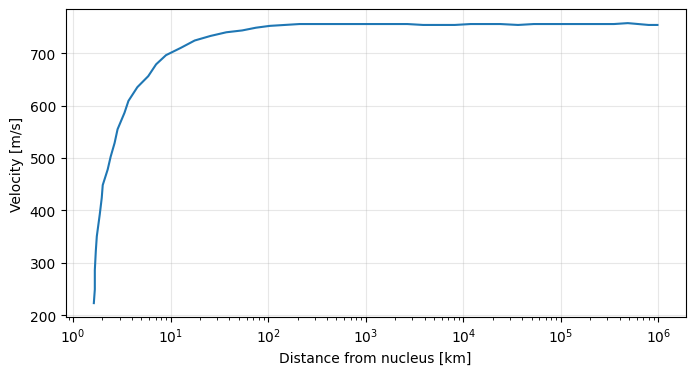

In [4]:
rkm = []
velocity_m_s = []
with open('../vel25au.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        rkm.append(float(row[0]))
        velocity_m_s.append(float(row[1]))

rkm = np.array(rkm)
velocity_m_s = np.array(velocity_m_s)

plt.figure(figsize=(8, 4))
plt.semilogx(rkm, velocity_m_s, color='tab:blue')
plt.xlabel('Distance from nucleus [km]')
plt.ylabel('Velocity [m/s]')
plt.grid(True, alpha=0.3)
plt.show()


xc: [1.00000000e+09 5.00000000e+08 4.00000000e+08 3.24638970e+08
 1.00752847e+08 4.68823931e+07 2.08553864e+07 9.92527780e+06
 5.65513526e+06 3.60581347e+06 2.40495798e+06 1.83587728e+06
 1.40145709e+06 1.06983293e+06 8.54271841e+05 6.52127099e+05
 4.54967585e+05 3.63295975e+05 2.83640818e+05 2.21450606e+05
 1.65287893e+05 1.17940031e+05 8.60703205e+04 6.14148811e+04
 4.48193752e+04 3.42138506e+04 2.49685968e+04 2.03913629e+04
 1.70321847e+04 1.27126043e+04 9.07099073e+03 7.24327299e+03
 5.91543887e+03 5.05339285e+03 4.12700675e+03 3.37044540e+03
 2.81521392e+03 2.19795878e+03 1.75509114e+03 1.00000000e+03]
xf: [1.41421356e+09 7.07106781e+08 4.47213595e+08 3.60354808e+08
 1.80854363e+08 6.87279754e+07 3.12690010e+07 1.43873383e+07
 7.49191487e+06 4.51567967e+06 2.94479709e+06 2.10123957e+06
 1.60402719e+06 1.22446925e+06 9.55995892e+05 7.46387177e+05
 5.44698716e+05 4.06556137e+05 3.21007115e+05 2.50624083e+05
 1.91319377e+05 1.39621127e+05 1.00752847e+05 7.27048726e+04
 5.24650036e+04

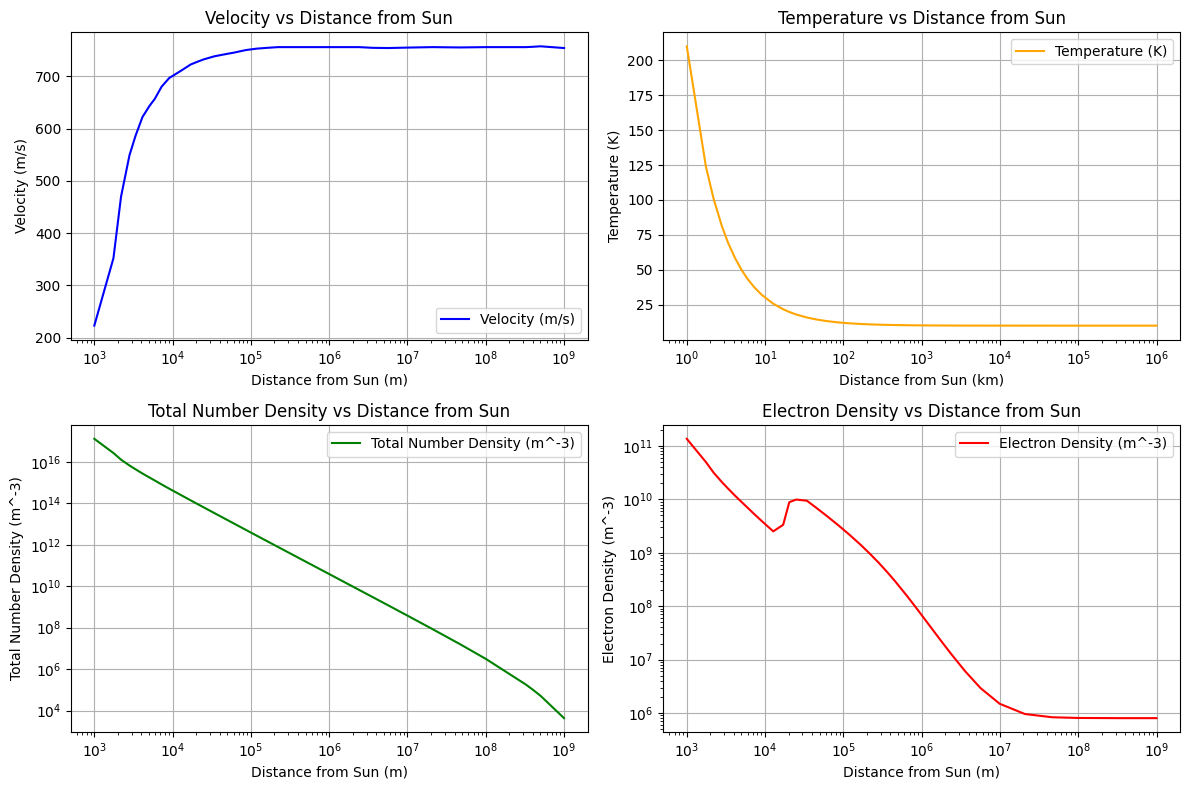

In [5]:
# Transition parameters
nu_Hz = 556.936e9
A_ul_s_1 = 3.456e-3
g_u = 9.0
g_l = 9.0
absorber_mass_kg = 18.01528 * constants.ATOMIC_MASS_UNIT

# Coma setup matching examples/coma.ipynb
heliocentric_distance_AU = 2.5
xc = radius_km * 1.0e3
xf = np.empty(xc.size + 1, dtype=np.float64)
xf[1:-1] = np.sqrt(xc[:-1] * xc[1:])
xf[0] = xc[0] ** 2 / xf[1]
xf[-1] = xc[-1] ** 2 / xf[-2]
nlayer = xc.size

print(f"xc: {xc}")
print(f"xf: {xf}")

v0 = 720.0
c_scale = 3.5e3
# velocity = velocity_tanh(xc, v0=v0, c=c_scale)
velocity = np.interp(xc, rkm*1e3, velocity_m_s)

T0 = 10.0
temperature = temperature_inverse_distance(xc, a=10, b=1, t0=T0, r0=2000)

Q = 3.7e26
total_number_density = calc_density(
    Q,
    xc,
    velocity,
    r_h=heliocentric_distance_AU,
    model_type='isotropic',
    photo_dissociation=True,
)
nelec, telec = electron_biver_1997(
    Q,
    r_h=heliocentric_distance_AU,
    r=xc,
    v=velocity,
    t_kin=temperature,
    t_emax=10000,
)

# Initial level ratios: rL0 = 0.5, rL1 = 0.5
fractions = np.zeros((nlayer, 1), dtype=np.float64)
fractions[:, 0] = level1_ratio
coma = ComaGrid(
    temperature=temperature,
    total_number_density=total_number_density,
    velocity=velocity,
    nelec=nelec,
    telec=telec,
    fractions=fractions,
)

coma.xf = xf
coma.xc = xc


# plot the profiles
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.semilogx(xc, velocity, label='Velocity (m/s)', color='blue')
plt.xlabel('Distance from Sun (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity vs Distance from Sun')
plt.grid()
plt.legend()    
plt.subplot(2, 2, 2)
plt.semilogx(xc/1000, temperature, label='Temperature (K)', color='orange')
plt.xlabel('Distance from Sun (km)')
plt.ylabel('Temperature (K)')
plt.title('Temperature vs Distance from Sun')
plt.grid()
plt.legend()
plt.subplot(2, 2, 3)
plt.loglog(xc, total_number_density, label='Total Number Density (m^-3)', color='green')
plt.xlabel('Distance from Sun (m)')
plt.ylabel('Total Number Density (m^-3)')
plt.title('Total Number Density vs Distance from Sun')
plt.grid()
plt.legend()
plt.subplot(2, 2, 4)
plt.loglog(xc, nelec, label='Electron Density (m^-3)', color='red')
plt.xlabel('Distance from Sun (m)')
plt.ylabel('Electron Density (m^-3)')
plt.title('Electron Density vs Distance from Sun')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()






In [6]:
B_ul_SI, B_lu_SI = einstein_coeffs_B(
    nu_Hz=nu_Hz,
    A_ul_s_1=A_ul_s_1,
    g_u=g_u,
    g_l=g_l,
)

Cm_ul_s_1 = np.asarray(
    molecular_collision_rate(coma.total_number_density, coma.temperature),
    dtype=np.float64,
)
Cm_lu_s_1 = np.asarray(
    detailed_balance_excitation_rate(
        Cm_ul_s_1,
        coma.temperature,
        nu_Hz=nu_Hz,
        g_u=g_u,
        g_l=g_l,
    ),
    dtype=np.float64,
)

electron_rates = np.array([
    electron_collision_rate(
        n_e=float(n_e),
        t_e=float(t_e),
        nu_Hz=nu_Hz,
        A_ul_s_1=A_ul_s_1,
        g_u=g_u,
        g_l=g_l,
    )
    for n_e, t_e in zip(coma.nelec, coma.telec)
], dtype=np.float64)
Ce_ul_s_1 = electron_rates[:, 0]
Ce_lu_s_1 = electron_rates[:, 1]

G_ul_s_1, G_lu_s_1 = scale_g_factors_from_1au(heliocentric_distance_AU)
G_ul_s_1 = np.full(nlayer, G_ul_s_1, dtype=np.float64)
G_lu_s_1 = np.full(nlayer, G_lu_s_1, dtype=np.float64)

print('Heliocentric distance [AU]:', heliocentric_distance_AU)
print('Production rate Q [s^-1]:', Q)
print('Initial lower-level density:', coma.density[:, 0])
print('Initial upper-level density:', coma.density[:, 1])


Heliocentric distance [AU]: 2.5
Production rate Q [s^-1]: 3.7e+26
Initial lower-level density: [4.27799620e+03 5.17281010e+04 1.00747504e+05 1.80638634e+05
 3.07350311e+06 1.59983499e+07 8.55603754e+07 3.87447610e+08
 1.20609238e+09 2.97857793e+09 6.70153201e+09 1.15145534e+10
 1.97783958e+10 3.39653838e+10 5.32945532e+10 9.14964440e+10
 1.88060127e+11 2.95001556e+11 4.84043452e+11 7.94195927e+11
 1.42813379e+12 2.81155029e+12 5.29860794e+12 1.04736075e+13
 1.97661503e+13 3.40760750e+13 6.44990803e+13 9.73712445e+13
 1.40483937e+14 2.56535328e+14 5.13645734e+14 8.25131908e+14
 1.28157837e+15 1.79328726e+15 2.77884079e+15 4.41818125e+15
 6.76634800e+15 1.29595465e+16 2.71524291e+16 1.31919791e+17]
Initial upper-level density: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [7]:
max_rt_iterations = 2000
jv_rtol = 1.0e-3
jv_floor = 1.0e-30
population_tolerance = 1.0e-10
packet_fraction_range = (0.05, 0.35)
random_seed = 7

history = []
previous_jv = None
converged = False

for iteration in range(1, max_rt_iterations + 1):
    rt_result = solve_rt_spherical(
        coma,
        lower_level=0,
        upper_level=1,
        nu_Hz=nu_Hz,
        A_ul_s_1=A_ul_s_1,
        g_u=g_u,
        g_l=g_l,
        absorber_mass_kg=absorber_mass_kg,
        n_mu=32,
        background_intensity_outer=0.0,
        background_intensity_inner=0.0,
        central_flux_nu_reference=0.0,
        central_flux_reference_radius_m=coma.xf[0],
    )
    jv_average_stream = np.asarray(rt_result['J_v_stream_average'], dtype=np.float64)
    base_level_ratio = coma.density[:, 0] / np.maximum(coma.density[:, 0] + coma.density[:, 1], 1.0e-300)
    if previous_jv is None:
        relative_change = np.full_like(jv_average_stream, np.inf)
    else:
        scale = np.maximum(np.abs(previous_jv), jv_floor)
        relative_change = np.abs(jv_average_stream - previous_jv) / scale
        if np.all(relative_change <= jv_rtol):
            history.append({
                'iteration': iteration,
                'J_v_stream_average': jv_average_stream.copy(),
                'J_nu_diffuse': np.asarray(rt_result['J_nu_diffuse']).copy(),
                'J_nu_beam': np.asarray(rt_result['J_nu_beam']).copy(),
                'F_nu': np.asarray(rt_result['F_nu']).copy(),
                'relative_change': relative_change.copy(),
                'tau_profile': np.asarray(rt_result['tau_profile']).copy(),
                'source_profile': np.asarray(rt_result['source_profile']).copy(),
                'excitation_temperature_K': np.asarray(rt_result['excitation_temperature_K']).copy(),
                'n_lower': coma.density[:, 0].copy(),
                'n_upper': coma.density[:, 1].copy(),
                'base_level_ratio': base_level_ratio.copy(),
                'population_iterations_used': 0,
            })
            converged = True
            print(f'Converged at RT iteration {iteration}.')
            break

    pop_result = monte_carlo_two_level_populations(
        coma,
        jv_average_stream,
        A_ul_s_1=A_ul_s_1,
        B_ul_SI=B_ul_SI,
        B_lu_SI=B_lu_SI,
        Cm_ul_s_1=Cm_ul_s_1,
        Cm_lu_s_1=Cm_lu_s_1,
        Ce_ul_s_1=Ce_ul_s_1,
        Ce_lu_s_1=Ce_lu_s_1,
        G_ul_s_1=G_ul_s_1,
        G_lu_s_1=G_lu_s_1,
        nu_Hz=nu_Hz,
        g_u=g_u,
        g_l=g_l,
        lower_level=0,
        upper_level=1,
        max_iterations=20000,
        tolerance=population_tolerance,
        packet_fraction_range=packet_fraction_range,
        random_seed=random_seed + iteration - 1,
    )

    history.append({
        'iteration': iteration,
        'J_v_stream_average': jv_average_stream.copy(),
        'J_nu_diffuse': np.asarray(rt_result['J_nu_diffuse']).copy(),
        'J_nu_beam': np.asarray(rt_result['J_nu_beam']).copy(),
        'F_nu': np.asarray(rt_result['F_nu']).copy(),
        'relative_change': relative_change.copy(),
        'tau_profile': np.asarray(rt_result['tau_profile']).copy(),
        'source_profile': np.asarray(rt_result['source_profile']).copy(),
        'excitation_temperature_K': np.asarray(rt_result['excitation_temperature_K']).copy(),
        'n_lower': np.asarray(pop_result['n_lower'], dtype=np.float64).copy(),
        'n_upper': np.asarray(pop_result['n_upper'], dtype=np.float64).copy(),
        'base_level_ratio': base_level_ratio.copy(),
        'population_iterations_used': int(pop_result['iterations_used']),
    })
    previous_jv = jv_average_stream

if not converged:
    print(f'No J_v convergence after {max_rt_iterations} RT iterations.')

final_state = history[-1]



Converged at RT iteration 11.


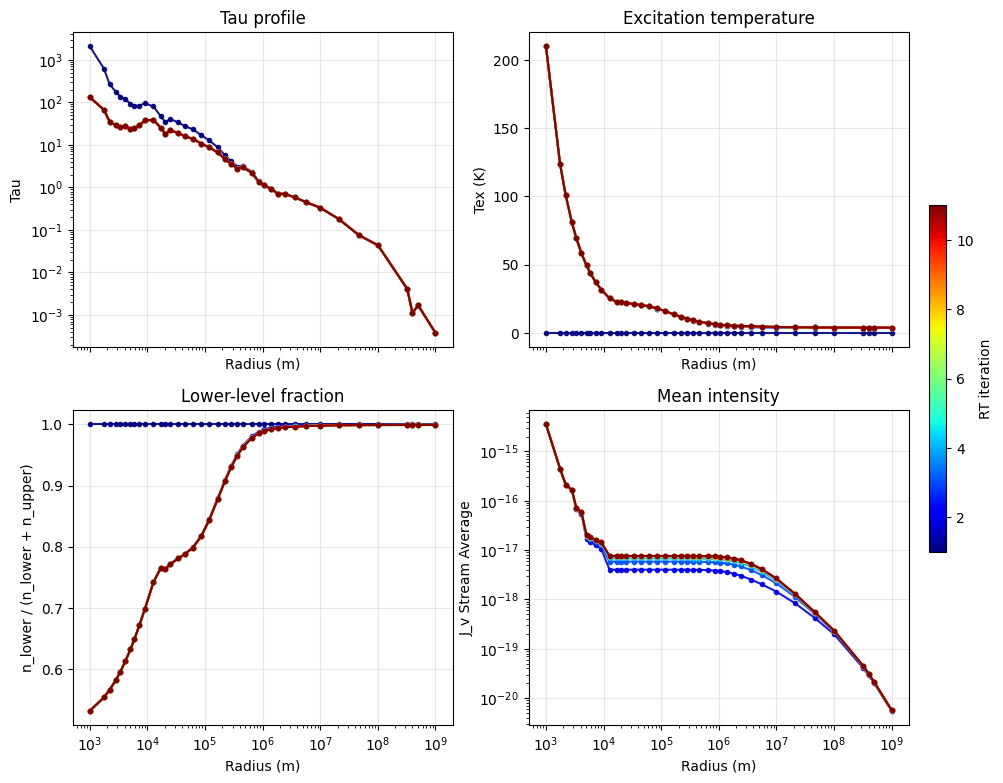

Final J_v_stream_average: [5.74966202e-21 2.10891098e-20 3.13989998e-20 4.43933737e-20
 2.32597097e-19 5.46480290e-19 1.31028304e-18 2.66047241e-18
 4.05789947e-18 5.26377746e-18 6.22787173e-18 6.70908622e-18
 7.07029872e-18 7.30672496e-18 7.42307143e-18 7.50035246e-18
 7.54759777e-18 7.56268968e-18 7.57301539e-18 7.57934861e-18
 7.58375297e-18 7.58648296e-18 7.58780952e-18 7.58855228e-18
 7.58891261e-18 7.58908398e-18 7.58919586e-18 7.58923832e-18
 7.58926403e-18 7.58929030e-18 1.43275470e-17 1.61173103e-17
 1.81308692e-17 2.00161696e-17 5.85233806e-17 7.04494032e-17
 1.65885628e-16 2.11891562e-16 4.46147573e-16 3.51176674e-15]
Final relative change: [3.66118009e-06 7.37390686e-06 1.71071681e-05 2.12402438e-05
 4.67139855e-05 9.77968470e-05 2.00231211e-04 3.47307661e-04
 4.52314156e-04 5.03718926e-04 5.16635483e-04 5.13288141e-04
 5.05312583e-04 4.97241883e-04 4.92330756e-04 4.88656950e-04
 4.86257979e-04 4.85476985e-04 4.84941753e-04 4.84613428e-04
 4.84385120e-04 4.84243618e-04 4.84

In [8]:

if history:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
    ax0, ax1, ax2, ax3 = axes.flatten()

    iterations = np.array([item['iteration'] for item in history], dtype=int)
    norm = mpl.colors.Normalize(vmin=iterations.min(), vmax=iterations.max())
    cmap = plt.cm.jet

    for item in history:
        color = cmap(norm(item['iteration']))
        label = f"Iter {item['iteration']}"
        ax0.loglog(coma.xc, item['tau_profile'], color=color, marker='.', linewidth=1.5, alpha=0.9)
        ax1.semilogx(coma.xc, item['excitation_temperature_K'], color=color, marker='.', linewidth=1.5, alpha=0.9)
        ax2.semilogx(coma.xc, item['base_level_ratio'], color=color, marker='.', linewidth=1.5, alpha=0.9)
        if item['iteration'] == 1: continue
        ax3.loglog(coma.xc, np.maximum(item['J_v_stream_average'], jv_floor), color=color, marker='.', linewidth=1.5, alpha=0.9, label=label)

    for ax in (ax0, ax1, ax2, ax3):
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('Radius (m)')

    ax0.set_ylabel('Tau')
    ax0.set_title('Tau profile')
    ax1.set_ylabel('Tex (K)')
    ax1.set_title('Excitation temperature')
    ax2.set_ylabel('n_lower / (n_lower + n_upper)')
    ax2.set_title('Lower-level fraction')
    ax3.set_ylabel('J_v Stream Average')
    ax3.set_title('Mean intensity')

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, pad=0.02, shrink=0.5)
    cbar.set_label('RT iteration')
    # cbar.set_position([0, 1])

    # plt.tight_layout()
    plt.show()

final_state = history[-1]
print('Final J_v_stream_average:', final_state['J_v_stream_average'])
print('Final relative change:', final_state['relative_change'])
print('Final n1/n0:', final_state['n_upper'] / np.maximum(final_state['n_lower'], 1.0e-300))

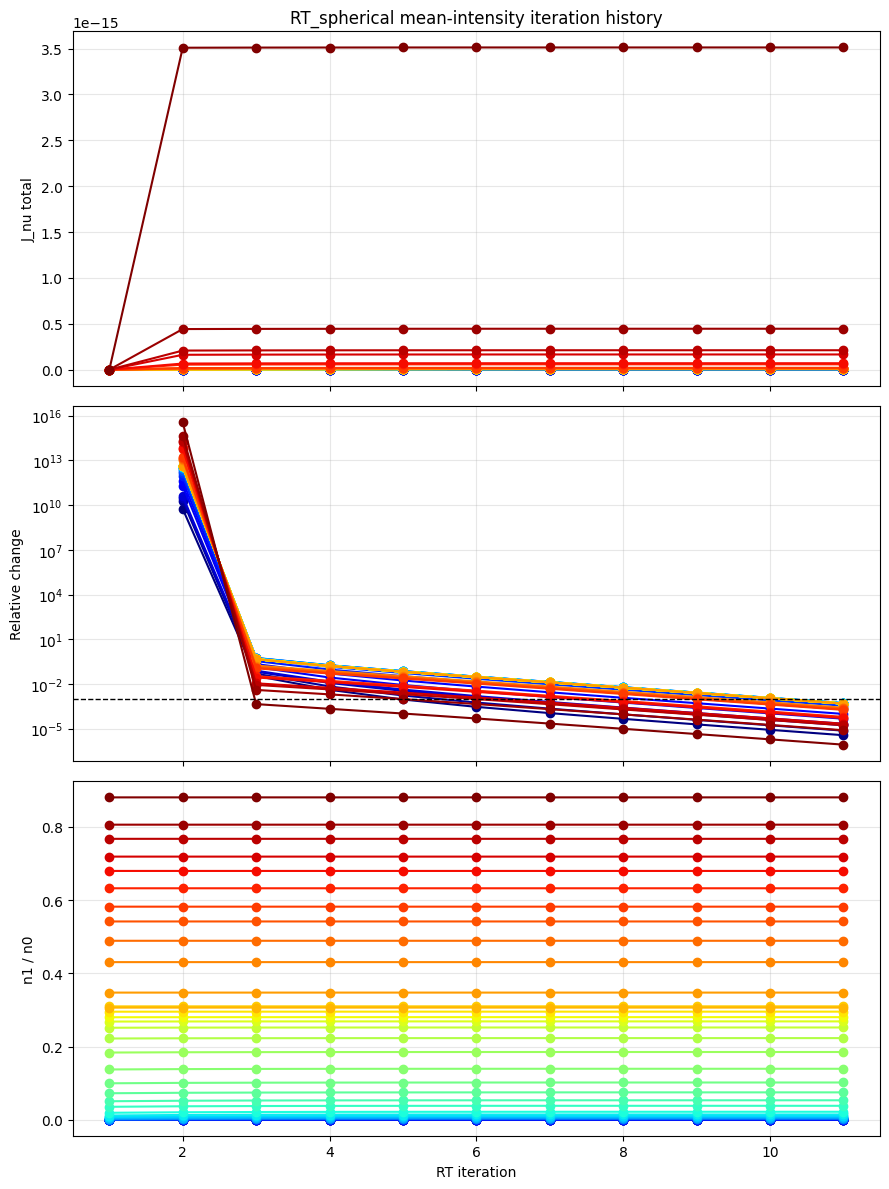

In [9]:
iterations = np.array([item['iteration'] for item in history], dtype=int)
jv_history = np.vstack([item['J_v_stream_average'] for item in history])
rel_history = np.vstack([item['relative_change'] for item in history])
ratio_history = np.vstack([
    item['n_upper'] / np.maximum(item['n_lower'], 1.0e-300)
    for item in history
])

fig, axes = plt.subplots(3, 1, figsize=(9, 12), sharex=True)
norm = mpl.colors.Normalize(vmin=0, vmax=nlayer - 1)
cmap = plt.cm.jet

for layer in range(nlayer):
    color = cmap(norm(layer))
    axes[0].plot(iterations, jv_history[:, layer], marker='o', color=color)
    axes[1].semilogy(iterations, np.maximum(rel_history[:, layer], 1.0e-16), marker='o', color=color)
    axes[2].plot(iterations, np.maximum(ratio_history[:, layer], 1.0e-30), marker='o', color=color)

axes[0].set_ylabel('J_nu total')
axes[0].set_title('RT_spherical mean-intensity iteration history')
axes[1].axhline(jv_rtol, color='k', linestyle='--', linewidth=1.0)
axes[1].set_ylabel('Relative change')
axes[2].set_xlabel('RT iteration')
axes[2].set_ylabel('n1 / n0')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


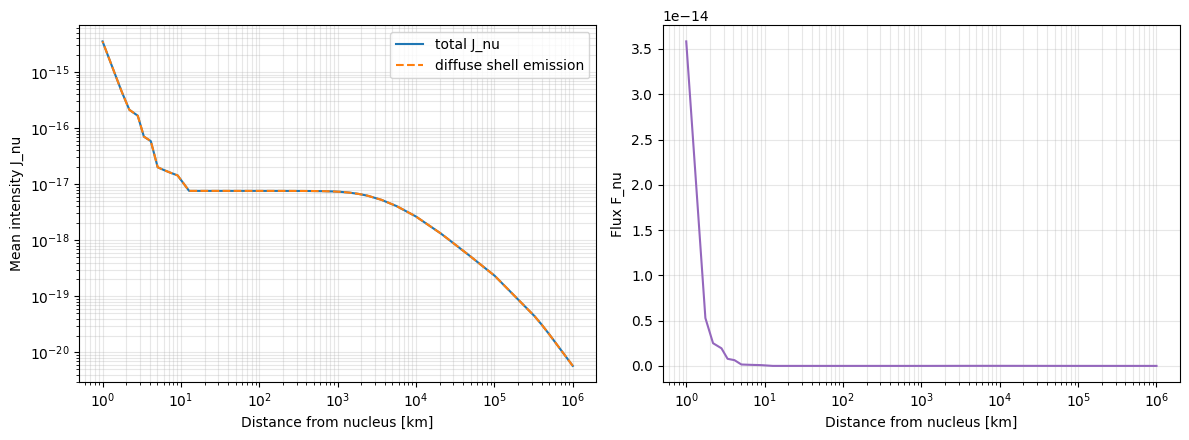

In [10]:
r_km = coma.xc * 1.0e-3
J_total = np.asarray(final_state['J_v_stream_average'], dtype=np.float64)
J_diffuse = np.asarray(final_state['J_nu_diffuse'], dtype=np.float64)
J_beam = np.asarray(final_state['J_nu_beam'], dtype=np.float64)
F_nu = np.asarray(final_state['F_nu'], dtype=np.float64)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].loglog(r_km, np.maximum(J_total, 1.0e-300), label='total J_nu')
axes[0].loglog(r_km, np.maximum(J_diffuse, 1.0e-300), '--', label='diffuse shell emission')
# axes[0].loglog(r_km, np.maximum(J_beam, 1.0e-300), ':', label='central beam')
axes[0].set_xlabel('Distance from nucleus [km]')
axes[0].set_ylabel('Mean intensity J_nu')
axes[0].legend()

axes[1].semilogx(r_km, F_nu, color='tab:purple')
axes[1].set_xlabel('Distance from nucleus [km]')
axes[1].set_ylabel('Flux F_nu')
for ax in axes:
    ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


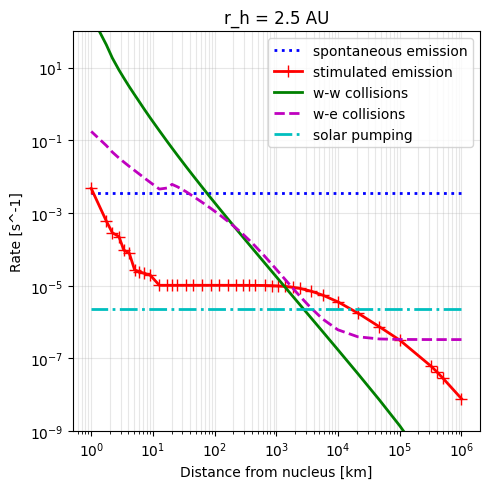

In [11]:
A_profile = np.broadcast_to(np.asarray(A_ul_s_1, dtype=np.float64), r_km.shape)
stimulated_profile = np.broadcast_to(np.asarray(B_ul_SI, dtype=np.float64), r_km.shape) * J_total
Cm_profile = np.broadcast_to(np.asarray(Cm_ul_s_1, dtype=np.float64), r_km.shape)
Ce_profile = np.broadcast_to(np.asarray(Ce_ul_s_1, dtype=np.float64), r_km.shape)
G_profile = np.broadcast_to(np.asarray(G_ul_s_1, dtype=np.float64), r_km.shape)

fig, ax = plt.subplots(figsize=(5, 5))
ax.loglog(r_km, A_profile, 'b:', lw=2, label='spontaneous emission')
ax.loglog(r_km, stimulated_profile, 'r+-', lw=2, markersize=8, label='stimulated emission')
ax.loglog(r_km, Cm_profile, 'g-', lw=2, label='w-w collisions')
ax.loglog(r_km, Ce_profile, 'm--', lw=2, label='w-e collisions')
ax.loglog(r_km, G_profile, 'c-.', lw=2, label='solar pumping')
ax.set_ylim(1.0e-9, 1.0e2)
ax.set_xlabel('Distance from nucleus [km]')
ax.set_ylabel('Rate [s^-1]')
ax.set_title('r_h = 2.5 AU')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
